<a href="https://colab.research.google.com/github/kjhaveri2321/Medical-LLM-Evaluation/blob/main/CS561_Group_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CS 561 Project**
# **Biomedical Summarization with BioInstruct**

This notebook:
# 1. Loads the BioInstruct dataset
# 2. Filters it for summarization-style tasks
# 3. Compares a biomedical baseline vs a stronger general model
# 4. Fine-tunes the stronger model with QLoRA
# 5. Evaluates all models with ROUGE, BLEU, and BERTScore


# 1. Install Packages

In [2]:
pip -q install -U transformers datasets accelerate peft trl bitsandbytes evaluate rouge_score bert_score sentencepiece

# 2. Import and Setup

In [3]:
import os
import re
import gc
import json
import random
import warnings
from typing import Dict, List

import numpy as np
import pandas as pd
import torch
from datasets import DatasetDict, load_dataset
import evaluate

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    set_seed,
)
from peft import LoraConfig, PeftModel
from trl import SFTTrainer

warnings.filterwarnings("ignore")

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


# 3. Configurations

In [4]:
DATASET_NAME = "bio-nlp-umass/bioinstruct"
BIO_MODEL_NAME = "khazarai/Bio-8B-it"
BASE_MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

PROJECT_DIR = "/content/cs561_project"
ADAPTER_DIR = os.path.join(PROJECT_DIR, "lora_model")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

MAX_TRAIN_SAMPLES = 8000
MAX_VAL_SAMPLES = 800
MAX_TEST_SAMPLES = 800

MAX_SEQ_LENGTH = 1024
USE_4BIT = True

# 4. Load and Filter Dataset

In [5]:
raw = load_dataset(DATASET_NAME)["train"]

SUMMARY_KEYWORDS = ["summarize","explain","simplify","rewrite","paraphrase"]

def is_summary(ex):
    instr = (ex.get("instruction") or "").lower()
    inp = (ex.get("input") or "")
    out = (ex.get("output") or "")
    return any(k in instr for k in SUMMARY_KEYWORDS) or (len(inp.split())>40 and len(out.split())<len(inp.split()))

filtered = raw.filter(is_summary)
print("Filtered size:", len(filtered))


Filtered size: 5709


# 5. Split and Prompt Format

In [6]:
s1 = filtered.train_test_split(test_size=0.2, seed=SEED)
s2 = s1["test"].train_test_split(test_size=0.5, seed=SEED)

train = s1["train"].select(range(min(MAX_TRAIN_SAMPLES, len(s1["train"]))))
val = s2["train"].select(range(min(MAX_VAL_SAMPLES, len(s2["train"]))))
test = s2["test"].select(range(min(MAX_TEST_SAMPLES, len(s2["test"]))))

splits = DatasetDict({"train":train,"validation":val,"test":test})

SYSTEM = "You are a biomedical assistant. Write a clear, concise summary."

def format_ex(ex):
    prompt = f"<|system|>\n{SYSTEM}\n<|user|>\nInstruction: {ex['instruction']}\nInput: {ex.get('input','')}\n<|assistant|>\n"
    return {"prompt":prompt,"reference":ex["output"],"text":prompt+ex["output"]}

splits = splits.map(format_ex)


# 6. Metrics and Other Helpers

In [7]:
rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")
bertscore = evaluate.load("bertscore")


def clean(x): return re.sub(r"\s+"," ",x).strip()

def compute(preds, refs):
    return {
        "rougeL": rouge.compute(predictions=preds,references=refs)["rougeL"],
        "bleu": bleu.compute(predictions=preds,references=[[r] for r in refs])["bleu"],
        "bertscore": np.mean(bertscore.compute(predictions=preds,references=refs,lang="en")["f1"])
    }


def load_model(name, train=False):
    tok = AutoTokenizer.from_pretrained(name, trust_remote_code=True)
    tok.pad_token = tok.eos_token

    # Important for decoder-only models during batched generation.
    # Left padding avoids the warning you saw and gives more reliable outputs.
    tok.padding_side = "left"

    model = AutoModelForCausalLM.from_pretrained(
        name,
        quantization_config=BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True,
            bnb_4bit_compute_dtype=torch.float16,
        ) if USE_4BIT else None,
        device_map="auto",
        trust_remote_code=True,
        dtype=torch.float16 if torch.cuda.is_available() else None,
    )

    if train:
        model.config.use_cache = False

    return model, tok

# 7. Baseline Evaluation

In [8]:
def evaluate_model(name, batch_size=4):
    m, t = load_model(name)
    subset = splits["test"].select(range(100))
    prompts = subset["prompt"]
    refs = subset["reference"]
    preds = []

    for i in range(0, len(prompts), batch_size):
        batch_prompts = prompts[i:i + batch_size]

        inputs = t(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LENGTH,
        ).to(m.device)

        with torch.no_grad():
            outputs = m.generate(
                **inputs,
                max_new_tokens=150,
                do_sample=False,
                use_cache=True,
                pad_token_id=t.pad_token_id,
                eos_token_id=t.eos_token_id,
            )

        decoded = t.batch_decode(outputs, skip_special_tokens=True)

        for full_text, prompt in zip(decoded, batch_prompts):
            pred = full_text[len(prompt):] if full_text.startswith(prompt) else full_text.replace(prompt, "", 1)
            preds.append(clean(pred))

    del m
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return compute(preds, refs)

bio_metrics = evaluate_model(BIO_MODEL_NAME, batch_size=4)
qwen_metrics = evaluate_model(BASE_MODEL_NAME, batch_size=4)

print("Bio model:", bio_metrics)
print("Qwen base:", qwen_metrics)

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Both `max_new_tokens` (=150) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=40960) seem to have been set. `max_new_tokens

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Bio model: {'rougeL': np.float64(0.05109686458261117), 'bleu': 0.007566157806034741, 'bertscore': np.float64(0.7514389413595199)}
Qwen base: {'rougeL': np.float64(0.25236804860325346), 'bleu': 0.07813420327702739, 'bertscore': np.float64(0.8815639001131058)}


## 7.1 Example outputs

In [9]:
import textwrap

def extract_answer(text):
    bad_tokens = [
        "<|system|>", "<|user|>", "<|assistant|>",
        "<|begin_of_text|>", "<|end_of_text|>",
        "<|start_of_answer|>", "<|end_of_answer|>",
        "<|begin|>", "<|end|>"
    ]
    for tok in bad_tokens:
        text = text.replace(tok, " ")
    return clean(text)


def split_prompt_fields(prompt):
    instruction = ""
    input_text = ""

    if "Instruction:" in prompt and "Input:" in prompt:
        after_instruction = prompt.split("Instruction:", 1)[1]
        instruction = after_instruction.split("Input:", 1)[0].replace("<|assistant|>", "").strip()
        input_text = after_instruction.split("Input:", 1)[1].replace("<|assistant|>", "").strip()

    return instruction, input_text


def build_bio_prompt(instruction, input_text):
    return f"Instruction: {instruction} Input: {input_text}Answer:"


def build_qwen_prompt(instruction, input_text):
    return (
        f"<|system|>{SYSTEM}"
        f"<|user|>Instruction: {instruction}Input: {input_text}"
        f"<|assistant|>"
    )


def generate_one(model, tokenizer, prompt, max_new_tokens=120):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            use_cache=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=False)
    if decoded.startswith(prompt):
        decoded = decoded[len(prompt):]

    return extract_answer(decoded)


def pretty_block(title, text, width=85, max_lines=4):
    wrapped = textwrap.wrap(text, width=width)
    wrapped = wrapped[:max_lines]
    if len(textwrap.wrap(text, width=width)) > max_lines:
        wrapped[-1] = wrapped[-1][:max(0, width-3)] + "..."
    print(f"{title}:")
    for line in wrapped:
        print(line)
    print()


def show_examples(n_examples=3):
    sample = splits["test"].select(range(n_examples))

    bio_model, bio_tok = load_model(BIO_MODEL_NAME)
    qwen_model, qwen_tok = load_model(BASE_MODEL_NAME)

    rows = []

    for i in range(len(sample)):
        original_prompt = sample[i]["prompt"]
        reference = clean(sample[i]["reference"])
        instruction, input_text = split_prompt_fields(original_prompt)

        bio_prompt = build_bio_prompt(instruction, input_text)
        qwen_prompt = build_qwen_prompt(instruction, input_text)

        bio_pred = generate_one(bio_model, bio_tok, bio_prompt, max_new_tokens=120)
        qwen_pred = generate_one(qwen_model, qwen_tok, qwen_prompt, max_new_tokens=120)

        if bio_pred == "" or bio_pred in ["<", "< <|end_of_text"]:
            bio_pred = "[No usable output generated by Bio-8B-it for this prompt format]"

        rows.append({
            "Example": i + 1,
            "Instruction": instruction,
            "Input": input_text,
            "Ground Truth": reference,
            "Bio-8B-it Output": bio_pred,
            "Qwen2.5-7B Output": qwen_pred,
        })

    examples_df = pd.DataFrame(rows)

    for _, row in examples_df.iterrows():
        print("=" * 100)
        print(f"EXAMPLE {row['Example']}")
        print("-" * 100)
        pretty_block("Instruction", row["Instruction"], width=85, max_lines=2)
        pretty_block("Input", row["Input"], width=85, max_lines=3)
        pretty_block("Ground Truth", row["Ground Truth"], width=85, max_lines=3)
        pretty_block("Bio-8B-it", row["Bio-8B-it Output"], width=85, max_lines=3)
        pretty_block("Qwen2.5-7B", row["Qwen2.5-7B Output"], width=85, max_lines=3)

    del bio_model, qwen_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return examples_df

# Running the examples
examples_df = show_examples(n_examples=2)
examples_df[["Example", "Instruction", "Ground Truth", "Bio-8B-it Output", "Qwen2.5-7B Output"]]

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Both `max_new_tokens` (=120) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


EXAMPLE 1
----------------------------------------------------------------------------------------------------
Instruction:
Given a medical procedure, explain the importance of informed consent and provide a
brief overview of the process.

Input:
What is informed consent and why is it important in medical procedures?

Ground Truth:
Informed consent is a process in which a healthcare provider explains to a patient
the potential benefits and risks of a medical procedure, as well as the patient's
right to accept or refuse the procedure. This process is important because it allo...

Bio-8B-it:
Informed consent is a process in which a patient is given information about a medical
procedure, including potential risks and benefits, and is asked to provide their
agreement to proceed. It is important because it ensures that the patient is fully...

Qwen2.5-7B:
Informed consent is a fundamental ethical and legal principle in medical practice
that ensures patients understand and agree to the detai

,Example,Instruction,Ground Truth,Bio-8B-it Output,Qwen2.5-7B Output
0,1,"Given a medical procedure, explain the importa...",Informed consent is a process in which a healt...,Informed consent is a process in which a patie...,Informed consent is a fundamental ethical and ...
1,2,Summarize a clinical trial study's primary obj...,The clinical trial aimed to test the effective...,The study aimed to evaluate the efficacy and s...,Summary: This clinical trial evaluated the eff...


# 8. QLoRA Setup

In [10]:
from trl import SFTTrainer, SFTConfig

# Load model/tokenizer for training
model, tok = load_model(BASE_MODEL_NAME, train=True)

train_sft = splits["train"].remove_columns(
    [c for c in splits["train"].column_names if c != "text"]
)
val_sft = splits["validation"].remove_columns(
    [c for c in splits["validation"].column_names if c != "text"]
)

print("Train columns:", train_sft.column_names)
print("Validation columns:", val_sft.column_names)

lora = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
)

args = SFTConfig(
    output_dir=ADAPTER_DIR,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=2,
    learning_rate=2e-4,
    logging_steps=20,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    report_to="none",
    fp16=False,
    bf16=True,
    max_length=MAX_SEQ_LENGTH,
    dataset_text_field="text",
    packing=False,
)

trainer = SFTTrainer(
    model=model,
    args=args,
    train_dataset=train_sft,
    eval_dataset=val_sft,
    processing_class=tok,
    peft_config=lora,
)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Train columns: ['text']
Validation columns: ['text']


Adding EOS to train dataset:   0%|          | 0/4567 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/4567 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/571 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/571 [00:00<?, ? examples/s]

# 9. Training

In [11]:
trainer.train()
trainer.save_model(ADAPTER_DIR)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Step,Training Loss,Validation Loss
100,0.781082,0.774313
200,0.762316,0.765429
300,0.680778,0.762499
400,0.680202,0.767477
500,0.681339,0.765820
572,0.687877,0.764389


# 10. Evaluating Fine-Tuned Model

In [12]:
base, tok = load_model(BASE_MODEL_NAME)
ft_model = PeftModel.from_pretrained(base, ADAPTER_DIR)

subset = splits["test"].select(range(100))
preds = []
for p in subset["prompt"]:
    inp = tok(p, return_tensors="pt").to(ft_model.device)
    out = ft_model.generate(**inp, max_new_tokens=150)
    preds.append(tok.decode(out[0], skip_special_tokens=True).replace(p,""))

ft_metrics = compute(preds, subset["reference"])
print("Fine-tuned:", ft_metrics)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Fine-tuned: {'rougeL': np.float64(0.4280395318258614), 'bleu': 0.21888109632202507, 'bertscore': np.float64(0.9259809613227844)}


# 11. Final Comparision

In [13]:
df = pd.DataFrame([
    {"model":"Bio-8B-it", **bio_metrics},
    {"model":"Qwen2.5-7B", **qwen_metrics},
    {"model":"Qwen2.5-7B + FT", **ft_metrics}
])
print(df)

# Save results
df.to_csv(os.path.join(RESULTS_DIR, "comparison.csv"), index=False)
print("Done.")


             model    rougeL      bleu  bertscore
0        Bio-8B-it  0.051097  0.007566   0.751439
1       Qwen2.5-7B  0.252368  0.078134   0.881564
2  Qwen2.5-7B + FT  0.428040  0.218881   0.925981
Done.


# Plot Model Comparision

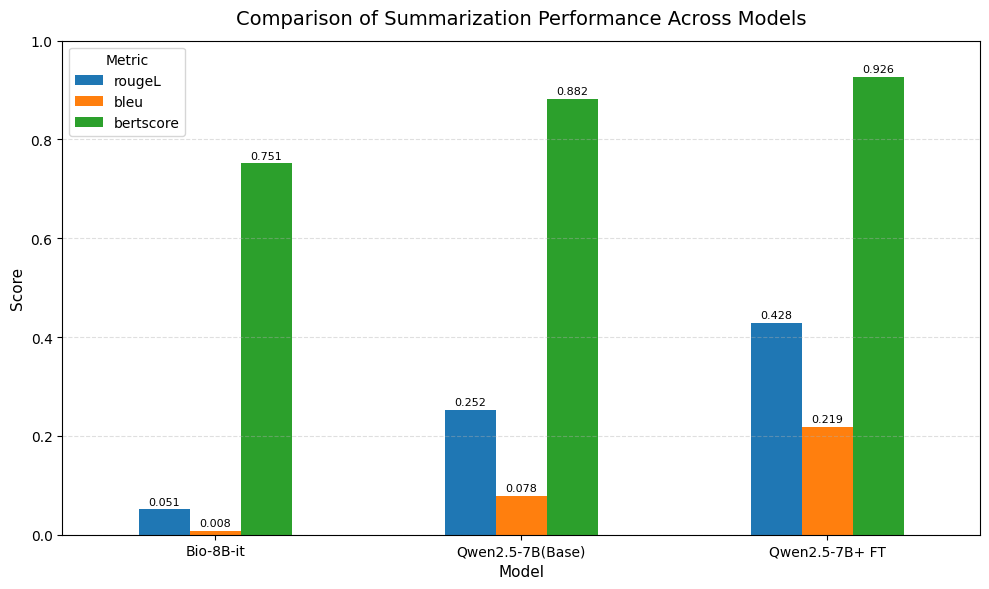

Plot saved to: /content/cs561_project/results/model_comparison_plot.png


In [16]:
import matplotlib.pyplot as plt

plot_df = df.copy()
plot_df["model"] = [
    "Bio-8B-it",
    "Qwen2.5-7B(Base)",
    "Qwen2.5-7B+ FT"
]
plot_df = plot_df.set_index("model")

metrics_to_plot = ["rougeL", "bleu", "bertscore"]
ax = plot_df[metrics_to_plot].plot(kind="bar", figsize=(10, 6), rot=0)

ax.set_title("Comparison of Summarization Performance Across Models", fontsize=14, pad=12)
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.0)
ax.legend(title="Metric")
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)

plt.tight_layout()

plot_path = os.path.join(RESULTS_DIR, "model_comparison_plot.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Plot saved to:", plot_path)


In [17]:
from google.colab import files
files.download(os.path.join(RESULTS_DIR, "comparison.csv"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>